# 01 — Data Cleaning & Preprocessing

**PM Accelerator — Tech Assessment (Data Scientist / Analyst Dual Role)**  
**Project:** Weather Trend Forecasting  
**Dataset:** [Global Weather Repository](https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository)

---

## Why this notebook exists

Raw data is rarely analysis-ready. Before EDA or forecasting we must:

1. **Understand** what each column means and how the data is structured over time  
2. **Fix** duplicates, bad types, and impossible values (outliers)  
3. **Simplify** by dropping redundant columns (same measurement in two units)  
4. **Normalize / scale** numeric features where models need comparable ranges  
5. **Save** a clean dataset so every later notebook starts from the same truth



## 1. Imports & paths

- `pandas` — tables and time series  
- `numpy` — numeric helpers  
- `matplotlib` / `seaborn` — quick visual checks for outliers  
- `sklearn.preprocessing` — MinMax / Standard scaling for modeling later

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Project root = parent of notebooks/
ROOT = Path("..").resolve()
RAW_PATH = ROOT / "data" / "raw" / "GlobalWeatherRepository.csv"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Raw file exists:", RAW_PATH.exists())
print("Raw path:", RAW_PATH)

Raw file exists: True
Raw path: E:\PM Accelerator\Data Science Intern\weather-trend-forecast\data\raw\GlobalWeatherRepository.csv


## 2. Load the raw data

**What to notice for this assessment:**
- Many cities worldwide, one row ≈ one weather snapshot  
- Time column for forecasting: `last_updated` (also `last_updated_epoch`)  
- Weather + air quality → Advanced track (environmental impact)

In [2]:
df = pd.read_csv(RAW_PATH, low_memory=False)

print("Shape (rows, columns):", df.shape)
print("Memory (MB):", round(df.memory_usage(deep=True).sum() / 1e6, 2))
df.head(3)

Shape (rows, columns): (153776, 41)
Memory (MB): 66.6


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.0,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.0,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.0,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


In [3]:
# Column inventory — know every feature before you drop or transform anything
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "nulls": df.isna().sum(),
    "nunique": df.nunique(dropna=True),
})
info

,dtype,non_null,nulls,nunique
country,str,153776,0,211
location_name,str,153776,0,268
latitude,float64,153776,0,422
longitude,float64,153776,0,428
timezone,str,153776,0,201
last_updated_epoch,int64,153776,0,1420
last_updated,str,153776,0,25587
temperature_celsius,float64,153776,0,708
temperature_fahrenheit,float64,153776,0,1179
condition_text,str,153776,0,57


## 3. Missing values

**Why it matters:** Models and correlations break or bias silently if NaNs are ignored.

**Strategies (pick based on context):**
- Drop rows / columns if almost empty  
- Impute (mean/median/mode, forward-fill for time series) if sparse gaps  

For *this* dataset we already saw **zero nulls** — we still document the check (good practice for assessors).

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(3)
missing_report = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_report = missing_report[missing_report["missing"] > 0].sort_values("missing", ascending=False)

if missing_report.empty:
    print("No missing values — no imputation needed.")
else:
    display(missing_report)
    print("Decide: drop vs impute based on % and feature importance.")

No missing values — no imputation needed.


## 4. Parse time correctly (`last_updated`)

**Why:** Forecasting is ordered in time. A string date sorts wrong (`"2024-10"` vs `"2024-2"` as text).  
Convert to `datetime64` so we can sort, resample, and plot trends.

Assessment requirement: *use `last_updated` for time series analysis.*

In [5]:
df["last_updated"] = pd.to_datetime(df["last_updated"], errors="coerce")

bad_dates = df["last_updated"].isna().sum()
print("Unparseable last_updated rows:", bad_dates)
print("Time range:", df["last_updated"].min(), "→", df["last_updated"].max())

# Optional calendar features (useful later for models)
df["date"] = df["last_updated"].dt.floor("D")
df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day_of_week"] = df["last_updated"].dt.dayofweek  # Mon=0

df[["country", "location_name", "last_updated", "date", "temperature_celsius"]].head()

Unparseable last_updated rows: 0
Time range: 2024-05-16 01:45:00 → 2026-07-17 19:00:00


,country,location_name,last_updated,date,temperature_celsius
0,Afghanistan,Kabul,2024-05-16 13:15:00,2024-05-16,26.6
1,Albania,Tirana,2024-05-16 10:45:00,2024-05-16,19.0
2,Algeria,Algiers,2024-05-16 09:45:00,2024-05-16,23.0
3,Andorra,Andorra La Vella,2024-05-16 10:45:00,2024-05-16,6.3
4,Angola,Luanda,2024-05-16 09:45:00,2024-05-16,26.0


## 5. Duplicates

**Why:** Duplicate rows double-count the same moment → biased averages and fake "extra" history.

We care most about duplicates of **(location + timestamp)** — same city, same update time.

In [6]:
exact_dups = df.duplicated().sum()
key_cols = ["country", "location_name", "last_updated"]
key_dups = df.duplicated(subset=key_cols).sum()

print("Exact duplicate rows:", exact_dups)
print("Duplicate (country, location, last_updated):", key_dups)

n_before = len(df)
df = df.drop_duplicates(subset=key_cols, keep="first").copy()
print(f"Rows after de-duplication: {n_before} → {len(df)} (removed {n_before - len(df)})")

Exact duplicate rows: 0
Duplicate (country, location, last_updated): 1
Rows after de-duplication: 153776 → 153775 (removed 1)


## 6. Outliers — detect and treat

### What is an outlier?
A value far from the rest of the distribution. It can be:
- a **real extreme** (heatwave, storm) → keep for climate / anomaly work  
- a **sensor / entry error** (wind 2963 kph) → fix or remove

### Methods we use here
1. **Domain rules** — physics / meteorology limits (preferred when you know them)  
2. **IQR rule** — flag values outside \([Q1 - 1.5\times IQR,\ Q3 + 1.5\times IQR]\)

For forecasting we **cap** (winsorize) clear sensor errors rather than deleting whole city days when possible.

In [7]:
def iqr_bounds(series: pd.Series, k: float = 1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


check_cols = [
    "temperature_celsius",
    "wind_kph",
    "pressure_mb",
    "precip_mm",
    "humidity",
    "air_quality_PM2.5",
]

outlier_summary = []
for col in check_cols:
    lo, hi = iqr_bounds(df[col])
    mask = (df[col] < lo) | (df[col] > hi)
    outlier_summary.append({
        "column": col,
        "iqr_low": round(lo, 2),
        "iqr_high": round(hi, 2),
        "n_flagged": int(mask.sum()),
        "pct": round(100 * mask.mean(), 2),
        "min": df[col].min(),
        "max": df[col].max(),
    })

pd.DataFrame(outlier_summary)

,column,iqr_low,iqr_high,n_flagged,pct,min,max
0,temperature_celsius,-1.60,45.60,2983,1.94,-29.800,79.30
1,wind_kph,-11.15,34.85,2567,1.67,3.600,2963.20
2,pressure_mb,998.00,1030.00,4257,2.77,947.000,3006.00
3,precip_mm,-0.03,0.05,30862,20.07,0.000,42.24
4,humidity,1.00,137.00,0,0.00,2.000,100.00
5,air_quality_PM2.5,-22.84,56.32,12812,8.33,0.168,1614.10


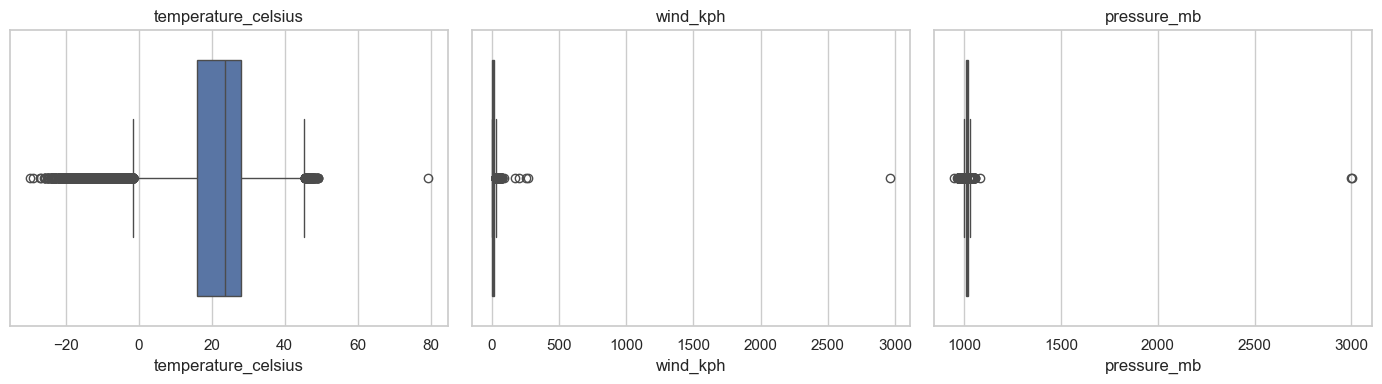

In [8]:
# Visual check — extreme tails stand out quickly
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["temperature_celsius", "wind_kph", "pressure_mb"]):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Domain caps (sensor-error style)

| Feature | Plausible range (approx.) | Why |
|---------|---------------------------|-----|
| Temperature °C | −50 to 55 | Beyond this is almost always bad data for city weather |
| Wind kph | 0 to 250 | Hurricane-level rare; 2000+ is impossible for this feed |
| Pressure mb | 870 to 1085 | Typical surface pressure envelope |
| Humidity % | 0 to 100 | Already bounded by definition |
| Precip mm | ≥ 0 | Negative precip is invalid |

We **clip** to these ranges and log how many rows were changed.

In [10]:
DOMAIN_CAPS = {
    "temperature_celsius": (-50, 55),
    "feels_like_celsius": (-55, 60),
    "wind_kph": (0, 250),
    "gust_kph": (0, 300),
    "pressure_mb": (870, 1085),
    "humidity": (0, 100),
    "cloud": (0, 100),
    "precip_mm": (0, None),  # lower only
    "visibility_km": (0, None),
    "uv_index": (0, 16),
}


def clip_column(series: pd.Series, lo, hi):
    before = series.copy()
    if lo is not None and hi is not None:
        after = series.clip(lower=lo, upper=hi)
    elif lo is not None:
        after = series.clip(lower=lo)
    else:
        after = series.clip(upper=hi)
    n_changed = int((before != after).sum())
    return after, n_changed


clip_log = []
for col, (lo, hi) in DOMAIN_CAPS.items():
    if col not in df.columns:
        continue
    df[col], n_changed = clip_column(df[col], lo, hi)
    clip_log.append({"column": col, "rows_clipped": n_changed, "new_min": df[col].min(), "new_max": df[col].max()})

pd.DataFrame(clip_log)

,column,rows_clipped,new_min,new_max
0,temperature_celsius,0,-29.8,55.00
1,feels_like_celsius,0,-36.7,60.00
2,wind_kph,0,3.6,250.00
3,gust_kph,0,3.6,300.00
4,pressure_mb,0,947.0,1085.00
5,humidity,0,2.0,100.00
6,cloud,0,0.0,100.00
7,precip_mm,0,0.0,42.24
8,visibility_km,0,0.0,32.00
9,uv_index,0,0.0,16.00


## 7. Drop redundant columns

**Why:** Same physical quantity in two units (e.g. °C and °F) adds correlation without new information and can confuse feature importance.

We keep **metric** units and drop imperial duplicates. We also drop `last_updated_epoch` once we have a proper datetime.

In [11]:
redundant = [
    "temperature_fahrenheit",
    "feels_like_fahrenheit",
    "wind_mph",
    "gust_mph",
    "pressure_in",
    "precip_in",
    "visibility_miles",
    "last_updated_epoch",  # duplicate of last_updated as datetime
]

to_drop = [c for c in redundant if c in df.columns]
df = df.drop(columns=to_drop)
print("Dropped:", to_drop)
print("Columns remaining:", len(df.columns))

Dropped: ['temperature_fahrenheit', 'feels_like_fahrenheit', 'wind_mph', 'gust_mph', 'pressure_in', 'precip_in', 'visibility_miles', 'last_updated_epoch']
Columns remaining: 37


## 8. Sort for time series

Forecasting assumes chronological order **within each location**.  
Sort by location then time so lag features and train/test splits by date are safe.

In [12]:
df = df.sort_values(["country", "location_name", "last_updated"]).reset_index(drop=True)

coverage = (
    df.groupby(["country", "location_name"], as_index=False)
    .agg(
        n_obs=("last_updated", "count"),
        first_obs=("last_updated", "min"),
        last_obs=("last_updated", "max"),
    )
    .sort_values("n_obs", ascending=False)
)

print("Locations:", len(coverage))
print("Obs per location — median:", coverage["n_obs"].median())
coverage.head(10)

Locations: 286
Obs per location — median: 787.0


,country,location_name,n_obs,first_obs,last_obs
36,Burundi,Bujumbura,791,2024-05-16 10:45:00,2026-07-17 07:45:00
260,Ukraine,Kyiv,791,2024-05-16 11:45:00,2026-07-17 09:00:00
278,Yemen,Sanaa,791,2024-05-16 11:45:00,2026-07-17 09:00:00
49,Chad,N'djamena,791,2024-05-16 09:45:00,2026-07-17 06:45:00
86,Ghana,Accra,791,2024-05-16 08:45:00,2026-07-17 05:45:00
272,Vatican City,Vatican City,791,2024-05-16 10:45:00,2026-07-17 07:45:00
74,Eritrea,Asmara,791,2024-05-16 11:45:00,2026-07-17 08:45:00
73,Equatorial Guinea,Malabo,791,2024-05-16 09:45:00,2026-07-17 07:00:00
149,Malta,Valletta,791,2024-05-16 10:45:00,2026-07-17 07:45:00
270,Uzbekistan,Tashkent,791,2024-05-16 13:45:00,2026-07-17 10:45:00


## 9. Normalization (scaling)

### Why scale?
Many models (neural nets, KNN, distance-based, regularized linear models) assume features on similar numeric scales.  
Tree models (Random Forest, XGBoost) are less sensitive — but the assessment asks for normalization, so we produce scaled copies.

| Scaler | Formula idea | When to use |
|--------|--------------|-------------|
| **MinMax** | map to [0, 1] | Bounded features, neural nets |
| **Standard** | mean 0, std 1 | Linear models, when outliers already handled |

**Important:** Fit scalers on **train** only in modeling notebooks to avoid leakage.  
Here we fit on the full cleaned table only to *save* a normalized artifact for exploration / demos — modeling notebooks will re-fit properly on train splits.

In [13]:
scale_cols = [
    "temperature_celsius",
    "feels_like_celsius",
    "wind_kph",
    "gust_kph",
    "pressure_mb",
    "precip_mm",
    "humidity",
    "cloud",
    "visibility_km",
    "uv_index",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10",
]
scale_cols = [c for c in scale_cols if c in df.columns]

minmax = MinMaxScaler()
standard = StandardScaler()

df_minmax = df.copy()
df_standard = df.copy()

df_minmax[scale_cols] = minmax.fit_transform(df[scale_cols])
df_standard[scale_cols] = standard.fit_transform(df[scale_cols])

print("MinMax sample (should be ~0–1):")
display(df_minmax[scale_cols].describe().loc[["min", "max"]].round(3))

print("Standard sample (mean ~0, std ~1):")
display(df_standard[scale_cols].describe().loc[["mean", "std"]].round(3))

MinMax sample (should be ~0–1):


,temperature_celsius,feels_like_celsius,wind_kph,gust_kph,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Standard sample (mean ~0, std ~1):


,temperature_celsius,feels_like_celsius,wind_kph,gust_kph,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
mean,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 10. Save cleaned outputs

| File | Use |
|------|-----|
| `weather_cleaned.csv` | Main file for EDA & modeling (original units) |
| `weather_minmax_scaled.csv` | Optional — neural / distance models |
| `weather_standard_scaled.csv` | Optional — linear models |
| `location_coverage.csv` | How much history each city has |

In [14]:
clean_path = PROCESSED_DIR / "weather_cleaned.csv"
minmax_path = PROCESSED_DIR / "weather_minmax_scaled.csv"
standard_path = PROCESSED_DIR / "weather_standard_scaled.csv"
coverage_path = PROCESSED_DIR / "location_coverage.csv"

df.to_csv(clean_path, index=False)
df_minmax.to_csv(minmax_path, index=False)
df_standard.to_csv(standard_path, index=False)
coverage.to_csv(coverage_path, index=False)

print("Saved:")
for p in [clean_path, minmax_path, standard_path, coverage_path]:
    print(" -", p, f"({p.stat().st_size / 1e6:.1f} MB)")

print("\nFinal cleaned shape:", df.shape)
print("Ready for notebook 02 — Exploratory Data Analysis.")

Saved:
 - E:\PM Accelerator\Data Science Intern\weather-trend-forecast\data\processed\weather_cleaned.csv (37.6 MB)
 - E:\PM Accelerator\Data Science Intern\weather-trend-forecast\data\processed\weather_minmax_scaled.csv (65.5 MB)
 - E:\PM Accelerator\Data Science Intern\weather-trend-forecast\data\processed\weather_standard_scaled.csv (74.4 MB)
 - E:\PM Accelerator\Data Science Intern\weather-trend-forecast\data\processed\location_coverage.csv (0.0 MB)

Final cleaned shape: (153775, 37)
Ready for notebook 02 — Exploratory Data Analysis.
